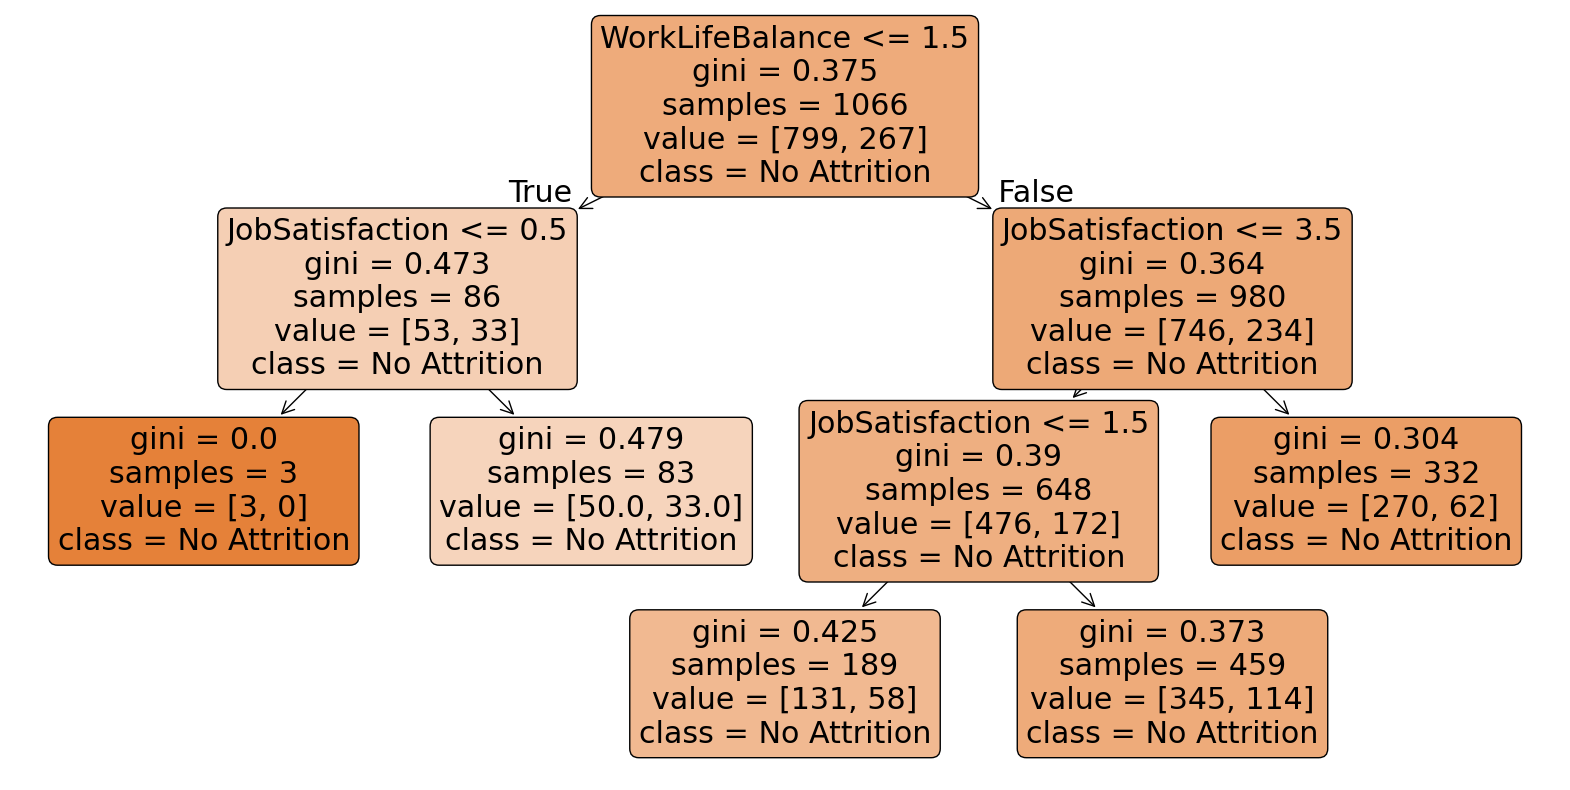

In [12]:
# Import resoruces 
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
#Import Model/s
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn import tree
import matplotlib.pyplot as plt 


#Load Data
hrdf = pd.read_excel("HRattritionClean.xlsx")

#Use Label Encoder for Marital status
lenc = LabelEncoder()
hrdf["MaritalStatus"] = lenc.fit_transform(hrdf["MaritalStatus"])
hrdf["Department"] = lenc.fit_transform(hrdf["Department"])

#Choose Feature Columns
X = hrdf[["WorkLifeBalance","JobSatisfaction", "MaritalStatus"]]
# X = hrdf[["MaritalStatus", "Department"]]
Y = hrdf["Attrition"]

#Split into Train and Test
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, Y, test_size=0.3, random_state=42)

#Train the model on train data
#model = DecisionTreeRegressor(max_depth=5, max_leaf_nodes=5)
model = DecisionTreeClassifier(max_depth=5, max_leaf_nodes=5)

model.fit(X_Train, Y_Train)

#Predict 
predictions = model.predict(X_Test)

#Check R2 Score or Metrics    
# print("Mean Squared Error : ",mean_squared_error(Y_Test, predictions))
# print("Mean Absolute Error : ", mean_absolute_error(Y_Test, predictions))
# print("RMSE : ",root_mean_squared_error(Y_Test, predictions))
#print("R2 Score : ",r2_score(Y_Test, predictions))

f1_score(Y_Test, predictions)

plt.figure(figsize=(20,10))
tree.plot_tree(model, feature_names=X_Train.columns, class_names=["No Attrition","Attrition"],filled=True, rounded=True)
#tree.plot_tree(model, feature_names=X_Train.columns,filled=True, rounded=True)
plt.show()


0.3348703386810169
              precision    recall  f1-score   support

           0       0.34      0.38      0.36      5643
           1       0.33      0.33      0.33      5418
           2       0.34      0.29      0.31      5589

    accuracy                           0.34     16650
   macro avg       0.34      0.34      0.33     16650
weighted avg       0.34      0.34      0.33     16650



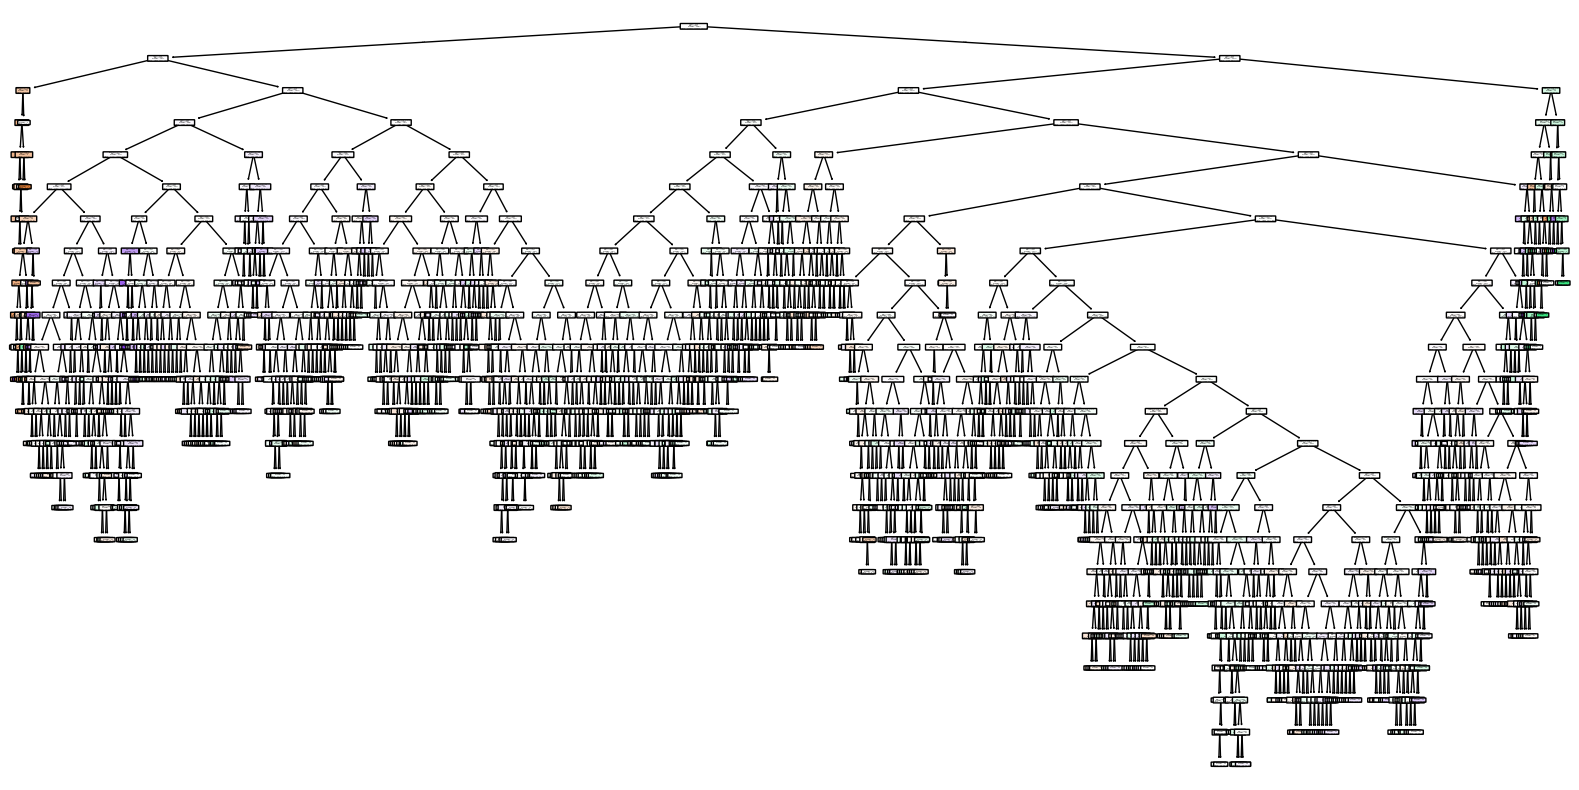

In [12]:
# Import resoruces 
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
#Import Model/s
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import f1_score, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn import tree
import matplotlib.pyplot as plt 

#Load Data
hrdf = pd.read_csv("healthcare_dataset.csv")

#Use Label Encoder
lenc = LabelEncoder()
hrdf["Gender"] = lenc.fit_transform(hrdf["Gender"])
hrdf["Admission Type"] = lenc.fit_transform(hrdf["Admission Type"])
hrdf["Test Results"] = lenc.fit_transform(hrdf["Test Results"])
hrdf["Medication"] = lenc.fit_transform(hrdf["Medication"])

#Choose Feature Columns
# X = hrdf[["WorkLifeBalance","JobSatisfaction", "MaritalStatus", "Department"]]
X = hrdf[["Age", "Admission Type", "Medication"]]
Y = hrdf["Test Results"]

#Split into Train and Test
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, Y, test_size=0.3, random_state=42)

#Train the model on train data
model = DecisionTreeClassifier()
model.fit(X_Train, Y_Train)

#Predict 
predictions = model.predict(X_Test)

#Check R2 Score or Metrics    
# print("Mean Squared Error : ",mean_squared_error(Y_Test, predictions))
# print("Mean Absolute Error : ", mean_absolute_error(Y_Test, predictions))
# print("RMSE : ",root_mean_squared_error(Y_Test, predictions))
# print("R2 Score : ",r2_score(Y_Test, predictions))
print(f1_score(Y_Test, predictions, average="weighted"))

# result = model.predict(["Age",45,"Admission Type",1])
# result

accuracy_score(Y_Test, predictions)
print(classification_report(Y_Test, predictions))

plt.figure(figsize=(20,10))
# tree.plot_tree(model, feature_names=X_Train.columns, class_names=["No 'Test Results'","'Test Results'"],filled=True, rounded=True)
tree.plot_tree(model, feature_names=X_Train.columns,filled=True, rounded=True)
plt.show()